# SecAntiGami — DLS analysis and figure generation

Analysis code for the dynamic light scattering (DLS) data in:

**SecAntiGami: A Secondary-Antibody-Inspired RNA Origami for Qualitative Aptamer Validation**
L. S. Frey, W. Verstraeten, M. P. Tran, D. Venkert, L. Monari, C. Geary, K. Göpfrich
*Nano Letters* (2026). DOI: [10.1021/acs.nanolett.6c03022](https://doi.org/10.1021/acs.nanolett.6c03022)

---

## What this notebook produces

| Section | Panel in the paper | Output file |
|---|---|---|
| 1 | **Figure 2E** — diameter increase vs SecAntiGami per Biotin-KL | `combined_titration.svg` |
| 2 | **Figure 2D** — Biotin-KL and negative controls | `combined_Biotin-KL.svg` |
| 3 | **Figure 3E** — screening of aptamer variants V1–V3 | `combined_Variants.svg` |
| 4 | **Supplementary Figure S8d** — SecAntiGami-1KL and N-Biotin-KL | `4KL_1KL_NBio_combined.svg` |

Run the sections in order. Sections 2 and 3 share the same processed
intermediates, so section 3 depends on section 2 having been run first.

## Input data

The DLS instrument (Malvern Panalytical Zetasizer Nano ZS ZEN3600, and a
Zetasizer Ultra for section 4) exports two data types. This notebook uses
**type II** only: one row per measurement, carrying the machine-computed mean
peak size in the `Pk 1 Mean Int (d.nm)` column.

Before the data reached this workflow, measurements the instrument flagged as
faulty (attenuator too high, count rate too low, and similar) and measurements
not used in the analysis (test runs) were removed from the `.txt` files by hand.

Technical triplicates are encoded in the last two characters of `Sample Name`;
the code strips them and aggregates. Replicate values are means of three
technical repeats; `n` throughout refers to independent replicates performed on
different days.

## How to run

```
pip install -r requirements.txt
jupyter lab DLS_analysis.ipynb
```

Raw `.txt` files go in `data/`. Processed tables and figures are written to
`output/` and `output/graphs/`, which are created automatically.

In [1]:
# Setup — paths, plotting defaults and colours
#
# All paths are relative to this notebook, so the repository runs as-is
# once the raw .txt files are placed in data/.

import os
import colorsys

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from uncertainties import ufloat
from uncertainties.umath import sqrt

DATA_DIR = '/Users/wverstra/Desktop/Main_author_projects/Secantigami/Nano letters submission/Gallery proof/Code/data'            # raw Zetasizer exports (.txt, tab-separated)
OUT_DIR = '/Users/wverstra/Desktop/Main_author_projects/Secantigami/Nano letters submission/Gallery proof/Code/output'           # processed tables (.csv)
FIG_DIR = os.path.join(OUT_DIR, "graphs")   # figures (.svg, .png)

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)


def hsla_to_rgba(h, s, l, a):
    h = h / 360.0
    r, g, b = colorsys.hls_to_rgb(h, l, s)
    return (r, g, b, a)


gray1 = hsla_to_rgba(0, 0, 0.5, 1)
gray2 = hsla_to_rgba(0, 0, 0.3, 1)
gray3 = hsla_to_rgba(0, 0, 0.7, 1)
blue1 = hsla_to_rgba(210, 1, 0.7, 1)   # bright blue
blue2 = hsla_to_rgba(210, 1, 0.2, 1)   # dark blue

# Keep text as text in the SVG output, so every symbol stays an editable object
mpl.rcParams.update({"text.usetex": False, "svg.fonttype": "none"})
pd.set_option("display.max_rows", None)

## 1 · Figure 2E — titration of SecAntiGami against Biotin-KL

Input: `Titration_main.txt`
Output: `output/graphs/combined_titration.svg`

Diameter increase of biotin-PE SUVs as a function of the SecAntiGami-to-aptamer
ratio. Two independent experiments with three technical repeats each.

In [2]:
# 1. Titration scatter plots (Data type: II, Topic: B)
# Part Ia: Data analysis: Aggregate the technical triplicates to calculate mean, standard deviation and standard error of the mean (SEM)
import os
import pandas as pd
import numpy as np
from uncertainties import ufloat
from uncertainties.umath import sqrt

# Paths to the input file
file_path = os.path.join(DATA_DIR, "Titration_main.txt")

def data_processing(file_path):
    #Reads in the file, truncates the last two characters of the group name (the triplicate numbering), and calculates mean, STD, and SEM of the triplicates using the data 
    # in the `Pk 1 Mean Int (d.nm)` column (which holds the information about the main peak of the distribution) using `ufloat` for uncertainty tracking.
    try:
        # Read file.
        df = pd.read_csv(file_path, sep="\t", encoding='latin1')
        
        # Remove the last two characters in `Sample Name`
        df['Sample Name'] = df['Sample Name'].str[:-2]
        
        # Replace commas with periods and convert to float
        df['Pk 1 Mean Int (d.nm)'] = df['Pk 1 Mean Int (d.nm)'].replace(',', '.', regex=True).astype(float)
        
        # Calculate mean, standard deviation, and SEM for each group using `ufloat`
        results = []
        for group, data in df.groupby('Sample Name'):
            values = data['Pk 1 Mean Int (d.nm)']
            mean_value = np.mean(values)
            std_value = np.std(values, ddof=1) # SD calculation with n-1
            sem_value = std_value / np.sqrt(len(values))  # SEM calculation
            
            # Create `ufloat` object for the mean with SEM as the uncertainty
            mean_with_uncertainty = ufloat(mean_value, sem_value)
            mean_with_std = ufloat(mean_value, std_value)
            
            # Combine results
            results.append({
                'Group': f"{group}",
                'Mean': mean_with_uncertainty.nominal_value,
                'Std': std_value,
                'Mean_with_std': mean_with_std,
                'SEM': sem_value,
                'Mean_with_uncertainty': mean_with_uncertainty,
                'Source': file_path
            })

        return pd.DataFrame(results)
    except Exception as e:
        print(f"Error reading the file {file_path}: {e}")
        return pd.DataFrame()  # Return an empty DataFrame if there's an error

# call function
results = data_processing(file_path)

# Output of combined results
print("Results from all files with triplicate distinction (including SEM and STD with `ufloat` for error propagation):")
print(results[['Group', 'Mean', 'Std','Mean_with_std' ,'SEM', 'Mean_with_uncertainty']])

# Save to a CSV file
output_path = os.path.join(OUT_DIR, "titration_combined_triplicates.csv")
results.to_csv(output_path, index=False)
print(f"The results have been saved to '{output_path}'.")

Results from all files with triplicate distinction (including SEM and STD with `ufloat` for error propagation):
          Group        Mean        Std  Mean_with_std        SEM  \
0       1 BSUVs  115.833333   3.601851        116+/-4   2.079530   
1     1 BSUVs 0  117.100000   1.322876    117.1+/-1.3   0.763763   
2   1 BSUVs 0.5  150.866667   0.757188    150.9+/-0.8   0.437163   
3     1 BSUVs 1  183.600000   2.787472    183.6+/-2.8   1.609348   
4     1 BSUVs 2  210.966667   2.700617    211.0+/-2.7   1.559202   
5     1 BSUVs 4  229.300000   6.596211        229+/-7   3.808324   
6     1 BSUVs 8  271.933333   6.958688        272+/-7   4.017600   
7       6 BSUVs  116.800000   0.100000  116.80+/-0.10   0.057735   
8     6 BSUVs 0  117.766667   1.401190    117.8+/-1.4   0.808977   
9   6 BSUVs 0.5  143.333333   2.020726    143.3+/-2.0   1.166667   
10    6 BSUVs 1  200.733333   3.650114        201+/-4   2.107394   
11    6 BSUVs 2  234.333333   5.350078        234+/-5   3.088869   
12  

In [3]:
# 1. Titration scatter plots (Data type: II, Topic: B)
# Part Ib: Data analysis: Calculate differences to the sample without RNA (the reference sample). (Calculating the increase out of the absolute size values)
import os
import pandas as pd
import numpy as np
from uncertainties import ufloat

# Read the file containing the triplicate results
input_path = os.path.join(OUT_DIR, "titration_combined_triplicates.csv")
data = pd.read_csv(input_path)

# Function to calculate differences with uncertainty propagation
def calculate_differences(data):
    # Identify reference and comparison rows
    reference_rows = data[data['Group'].str.contains("1 BSUVs|6 BSUVs") & ~data['Group'].str.contains(" 0| 0.5| 1| 2| 4| 8")]
    comparison_rows = data[data['Group'].str.contains("1 BSUVs|6 BSUVs") & data['Group'].str.contains(" 0| 0.5| 1| 2| 4| 8")]

    results = []
    
    for ref_idx, ref_row in reference_rows.iterrows():
        ref_group = ref_row['Group']
        #ref_mean = ufloat(ref_row['Mean'], ref_row['SEM'])  # Use ufloat for reference mean
        ref_mean = ufloat(ref_row['Mean'], ref_row['Std']) # Given that the inter repeat variability is higher than the intra repetas, we should use the std of the means
        # Find comparison groups related to this reference sample
        for comp_idx, comp_row in comparison_rows.iterrows():
            if comp_row['Group'].startswith(ref_group):
                #comp_mean = ufloat(comp_row['Mean'], comp_row['SEM'])  # Use ufloat for comparison mean
                comp_mean = ufloat(comp_row['Mean'], comp_row['Std'])
                # Calculate the differences for means and SEMs
                delta_mean = comp_mean - ref_mean  # Ufloat automatically handles error propagation

                results.append({
                    'Group': comp_row['Group'],
                    'Delta Mean': delta_mean.nominal_value,
                    #'Delta SEM': delta_mean.std_dev,  # Propagated SEM
                    'Delta Std': delta_mean.std_dev, #Propagated std
                    'Reference Group': ref_group
                })

    return pd.DataFrame(results)


# Call function and perform calculations
difference_results = calculate_differences(data)

# Display results
print("Difference results between reference and comparison samples:")
print(difference_results)

# Save results
output_diff_path = os.path.join(OUT_DIR, "titration_differences.csv")
difference_results.to_csv(output_diff_path, index=False)
print(f"The difference results have been saved at '{output_diff_path}'.")

Difference results between reference and comparison samples:
          Group  Delta Mean  Delta Std Reference Group
0     1 BSUVs 0    1.266667   3.837100         1 BSUVs
1   1 BSUVs 0.5   35.033333   3.680580         1 BSUVs
2     1 BSUVs 1   67.766667   4.554485         1 BSUVs
3     1 BSUVs 2   95.133333   4.501851         1 BSUVs
4     1 BSUVs 4  113.466667   7.515539         1 BSUVs
5     1 BSUVs 8  156.100000   7.835603         1 BSUVs
6     6 BSUVs 0    0.966667   1.404754         6 BSUVs
7   6 BSUVs 0.5   26.533333   2.023199         6 BSUVs
8     6 BSUVs 1   83.933333   3.651484         6 BSUVs
9     6 BSUVs 2  117.533333   5.351012         6 BSUVs
10    6 BSUVs 4  157.466667  10.095213         6 BSUVs
11    6 BSUVs 8  209.733333  25.718735         6 BSUVs
The difference results have been saved at '/Users/wverstra/Desktop/Main_author_projects/Secantigami/Nano letters submission/Gallery proof/Code/output/titration_differences.csv'.


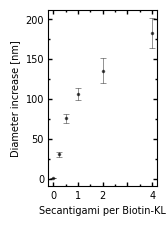

In [4]:
# 1. Titration scatter plots (Data type: II, Topic: B)
# Part II: Plotting
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator, MaxNLocator

# Read in the file with the differences
input_path = os.path.join(OUT_DIR, "titration_differences.csv")
data = pd.read_csv(input_path)

# Define group order: BSUVs stands for biotinylated SUVs. In the first sample only the aptamer was added. The number shows the rough concentration of added Secantigami. 
order= ['BSUVs 0', 'BSUVs 0.5', 'BSUVs 1', 'BSUVs 2', 'BSUVs 4','BSUVs 8']

# Sort the data. The group names have a 1 or 6 in front which is just ther to distinguish the different experiments. This has to be removed for comparison with the order names.

sao_names = ['0', '', '', '1', '2', '4'] # Costum x-axis labels indicating the relative amount of Secantigami per aptamer.
x_positions = [0, 0.5, 1, 2, 4, 8] # set x-positions

# main function for the plot
def main_plot_overall(data):
    cm_to_inch = lambda cm: cm / 2.54 #translates cm to inch to be able to work with cm.
    fig, ax = plt.subplots(figsize=(cm_to_inch(4.5), cm_to_inch(6)), dpi=100) # set plot size

    # Scatter plot for the data of the first experiment (indicated by a 1 at the beginning of the group name).
    for idx, group in enumerate(order):
        # Filter the points and errors for the current group
        group_pointsD1 = data[data['Group'] == f"1 {group}"]['Delta Mean']
        #group_errors = data[data['Group'] == f"1 {group}"]['Delta SEM']
        group_errorsD1 = data[data['Group'] == f"1 {group}"]['Delta Std']
        # Filter the points and errors for the current group
        group_pointsD2 = data[data['Group'] == f"6 {group}"]['Delta Mean']
        #group_errors = data[data['Group'] == f"6 {group}"]['Delta SEM']
        group_errorsD2 = data[data['Group'] == f"6 {group}"]['Delta Std']
        group_points = np.mean([group_pointsD1, group_pointsD2])
        group_errors = np.std([group_pointsD1, group_pointsD2])/np.sqrt(2)

        # Plot each point with an error bar
        ax.errorbar(
            np.full(1, x_positions[idx]), # x positions
            group_points,                     # y values
            yerr=group_errors,                # y errors
            fmt='o',                          # point marker
            color='black',                    # point color
            markersize=1.5,                   # point size
            alpha=0.6,                        # transparency
            capsize=2.5,                      # error cap size
            elinewidth=0.5,                   # error line width
            capthick=0.5,                     # cap thickness
            zorder=2                          # layering
        )   

    # Add axis labels
    ax.set_ylabel('Diameter increase [nm]', fontsize=7)
    ax.set_xlabel('Secantigami per Biotin-KL', fontsize=7)

    # Edit axis layouts 
    ax.tick_params(axis='y', labelsize=7)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(sao_names, fontsize=7)
    ax.tick_params(axis='both', which='both', direction='in', labelsize=7, length=3, width=1, pad=3)
    ax.tick_params(axis='both', which='minor', length=1.5)
    ax.xaxis.set_major_locator(MultipleLocator(2))
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    ax.yaxis.set_minor_locator(MultipleLocator(25))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.xaxis.set_ticks_position('both')
    ax.yaxis.set_ticks_position('both')
    ax.tick_params(axis='both', direction='in')


    # Show and save the plot
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "combined_titration.png"), format='png', dpi=300, bbox_inches='tight', pad_inches=0.1) # The directory might needs to be added first.
    plt.savefig(os.path.join(FIG_DIR, "combined_titration.svg"), format='svg', dpi=300, bbox_inches='tight', pad_inches=0.1)
    plt.show()

# call function
main_plot_overall(data)

## 2 · Figure 2D — Biotin-KL and the negative controls

Inputs: `241011_clean.txt`, `241015_clean.txt`, `241022_clean.txt`, `241022_additional.txt`
Output: `output/graphs/combined_Biotin-KL.svg`

Diameter increase in the presence or absence of SecAntiGami, biotin-PE lipids
and Biotin-KL aptamer. The four input files are separate independent
experiments; prefixes A–D are attached so that identically named samples from
different days stay distinguishable.

In [5]:
# 2. Main comparison bar/ scatter plots (Data type II, Topic A)
# Part Ia: Data analysis: Aggregate the technical triplicates to calculate mean, standard deviation and standard error of the mean (SEM)
# The main problem here is that all samples with the same conditions but from different experiments have the exact same name. To identify them, one data set was split and suffixes were attached to each name.
import os
import pandas as pd
import numpy as np
from uncertainties import ufloat
from uncertainties.umath import sqrt

# Paths to the input files. Here, each experiment has its own file.
file_paths = [
    os.path.join(DATA_DIR, "241011_clean.txt"), # Removed faulty data (see introduction)
    os.path.join(DATA_DIR, "241015_clean.txt"), # Removed faulty data (see introduction)
    os.path.join(DATA_DIR, "241022_clean.txt"), # Removed faulty data (see introduction) and one repetition of a sample...
    os.path.join(DATA_DIR, "241022_additional.txt") #... which is placed in this extra file to be able to keep the same sample name without confusion.
]

# Assigned prefixes for the triplicates based on file association
triplicate_prefixes = ['A', 'B', 'C', 'D']

def data_processing(file_path, prefix):
    #Reads in the file, truncates the last two characters of the group name (the triplicate numbering), and calculates mean, STD, and SEM of the triplicates using the data 
    # in the `Pk 1 Mean Int (d.nm)` column (which holds the information about the main peak of the distribution) using `ufloat` for uncertainty tracking.
    try:
        # Read file and replace commas in the `Pk 1 Mean Int (d.nm)` column
        df = pd.read_csv(file_path, sep="\t", encoding='latin1')
        
        # Remove the last two characters in `Sample Name`
        df['Sample Name'] = df['Sample Name'].str[:-2]
        
        # Replace commas with periods and convert to float
        df['Pk 1 Mean Int (d.nm)'] = df['Pk 1 Mean Int (d.nm)'].replace(',', '.', regex=True).astype(float)
        
        # Calculate mean, standard deviation, and SEM for each group
        results = []
        for group, data in df.groupby('Sample Name'):
            values = data['Pk 1 Mean Int (d.nm)']
            mean_value = np.mean(values)
            std_value = np.std(values, ddof=1) # SD calculation with n-1
            sem_value = std_value / np.sqrt(len(values))  # SEM calculation
            
            # Create `ufloat` object for the mean with SEM as the uncertainty 
            mean_with_uncertainty = ufloat(mean_value, sem_value)
            
            results.append({
                'Group': f"{prefix} {group}",
                'Mean': mean_with_uncertainty.nominal_value,
                'Std': std_value,
                'SEM': sem_value,
                'Mean_with_uncertainty': mean_with_uncertainty,
                'Source': file_path
            })

        return pd.DataFrame(results)
    except Exception as e:
        print(f"Error reading the file {file_path}: {e}")
        return pd.DataFrame()  # Return an empty DataFrame if there's an error

# Main DataFrame to collect results from all files
combined_results = pd.DataFrame()

# Iterate over files and process
for i, path in enumerate(file_paths):
    prefix = triplicate_prefixes[i]
    file_results = data_processing(path, prefix)
    combined_results = pd.concat([combined_results, file_results], ignore_index=True)

# Output of combined results
print("Results from all files with triplicate distinction (including SEM and STD):")
print(combined_results[['Group', 'Mean', 'Std', 'SEM', 'Mean_with_uncertainty']])

# Save to a CSV file
output_path = os.path.join(OUT_DIR, "variants_combined_triplicates.csv")
combined_results.to_csv(output_path, index=False)
print(f"The results have been saved to '{output_path}'.")

Results from all files with triplicate distinction (including SEM and STD):
           Group        Mean         Std         SEM Mean_with_uncertainty
0      A 1 BSUVs  115.566667    1.101514    0.635959           115.6+/-0.6
1    A 1 BSUVs A  117.633333    2.218859    1.281059           117.6+/-1.3
2   A 1 BSUVs AS  224.633333    0.802081    0.463081           224.6+/-0.5
3      A 2 DSUVs  127.633333    2.345918    1.354417           127.6+/-1.4
4    A 2 DSUVs A  127.500000    2.170253    1.252996           127.5+/-1.3
5   A 2 DSUVs AS  125.500000    1.153256    0.665833           125.5+/-0.7
6      A 3 BSUVs  118.166667    1.913984    1.105039           118.2+/-1.1
7    A 3 BSUVs A  119.166667    1.484363    0.856997           119.2+/-0.9
8   A 3 BSUVs AS  190.966667    2.081666    1.201850           191.0+/-1.2
9      A 4 BSUVs  117.666667    0.723418    0.417665           117.7+/-0.4
10   A 4 BSUVs A  116.933333    0.577350    0.333333         116.93+/-0.33
11  A 4 BSUVs AS  198.13

In [6]:
# 2. Main comparison bar/ scatter plots (Data type: II, Topic: A)
# Part Ib: Data analysis: Calculate differences to the sample without RNA (the reference sample). (Calculating the increase out of the absolute size values)
import os
import pandas as pd
from uncertainties import ufloat

# Read the output file containing triplicate results with ufloat
input_path = os.path.join(OUT_DIR, "variants_combined_triplicates.csv")
data = pd.read_csv(input_path)

# Function to calculate differences with uncertainty propagation
def calculate_differences(data):
    # Identify reference and comparison rows
    reference_rows = data[data['Group'].str.contains("SUVs") & ~data['Group'].str.contains(" AS| S| A")] # S = Secantigami added, A = Aptamer added, AS = both (The reference has no addition!)
    comparison_rows = data[data['Group'].str.contains("SUVs") & data['Group'].str.contains(" AS| S| A")]

    results = []
    
    for ref_idx, ref_row in reference_rows.iterrows():
        ref_group = ref_row['Group']
        ref_mean = ufloat(ref_row['Mean'], ref_row['SEM'])  # Use ufloat for reference mean

        # Find comparison groups related to this reference sample
        for comp_idx, comp_row in comparison_rows.iterrows():
            if comp_row['Group'].startswith(ref_group):
                comp_mean = ufloat(comp_row['Mean'], comp_row['SEM'])  # Use ufloat for comparison mean

                # Calculate the differences for means, standard deviations, and SEMs
                delta_mean = comp_mean - ref_mean  # Automatically handles error propagation

                results.append({
                    'Group': comp_row['Group'],
                    'Delta Mean': delta_mean.nominal_value,
                    'Delta SEM': delta_mean.std_dev,  # Propagated SEM
                    'Reference Group': ref_group
                })

    return pd.DataFrame(results)

# Call function and perform calculations
difference_results = calculate_differences(data)

# Display results
print("Difference results between reference and comparison samples:")
print(difference_results)

# Optional: Save results
output_diff_path = os.path.join(OUT_DIR, "variants_differences.csv")
difference_results.to_csv(output_diff_path, index=False)
print(f"The difference results have been saved at '{output_diff_path}'.")

Difference results between reference and comparison samples:
           Group  Delta Mean   Delta SEM Reference Group
0    A 1 BSUVs A    2.066667    1.430229       A 1 BSUVs
1   A 1 BSUVs AS  109.066667    0.786695       A 1 BSUVs
2    A 2 DSUVs A   -0.133333    1.845114       A 2 DSUVs
3   A 2 DSUVs AS   -2.133333    1.509231       A 2 DSUVs
4    A 3 BSUVs A    1.000000    1.398412       A 3 BSUVs
5   A 3 BSUVs AS   72.800000    1.632653       A 3 BSUVs
6    A 4 BSUVs A   -0.733333    0.534374       A 4 BSUVs
7   A 4 BSUVs AS   80.466667    0.669992       A 4 BSUVs
8    A 5 BSUVs A   45.133333    4.895009       A 5 BSUVs
9   A 5 BSUVs AS  327.633333   17.041453       A 5 BSUVs
10   A 6 BSUVs A    2.400000    1.427118       A 6 BSUVs
11  A 6 BSUVs AS  152.133333    5.998148       A 6 BSUVs
12   A 7 BSUVs S    5.300000    0.576387       A 7 BSUVs
13   B 1 BSUVs A    5.900000    1.681269       B 1 BSUVs
14  B 1 BSUVs AS   76.566667    2.262251       B 1 BSUVs
15   B 2 DSUVs A    0.73333

In [7]:
# 2. Main comparison bar/ scatter plots (Data type: II, Topic: A)
# Part Ic: Data analysis: Calculate the means of a sample throughout all experiments.

import os
import pandas as pd
import numpy as np
from uncertainties import ufloat

# Input path
input_path = os.path.join(OUT_DIR, "variants_differences.csv")

# Read the difference results file
data = pd.read_csv(input_path)

# Remove the first two characters from the 'Group' name to identify main groups (The first two characters contain the prefix used to distinguish between the experiments.)
data['Main Group'] = data['Group'].str[2:]

# Function to calculate propagated SEM using ufloat
def calculate_sem_error_propagation(uncertainties):
    propagated_value = ufloat(0, 0)  # Start with a ufloat object with zero value
    for u in uncertainties:
        propagated_value += u  # Accumulate using ufloat
    return propagated_value.std_dev / np.sqrt(len(uncertainties))  # Propagated SEM

# Calculate overall mean, propagated STD, and SEM for each main group
grouped_results = data.groupby('Main Group').agg(
    Overall_Mean=('Delta Mean', 'mean'),
    Propagated_SEM=('Delta SEM', lambda x: calculate_sem_error_propagation([ufloat(mean, sem) for mean, sem in zip(x, data.loc[x.index, 'Delta SEM'])]))
).reset_index()

# Display results
print("Group means:")
print(grouped_results)

# Save results to a new CSV file
output_path = os.path.join(OUT_DIR, "variants_groupmeans.csv")
grouped_results.to_csv(output_path, index=False)
print(f"The grouped means, standard deviations, and SEMs (with error propagation) have been saved to '{output_path}'.")

Group means:
    Main Group  Overall_Mean  Propagated_SEM
0    1 BSUVs A      2.916667        1.414312
1   1 BSUVs AS     51.383333        1.748015
2    2 DSUVs A     -0.066667        1.443889
3   2 DSUVs AS     -0.966667        1.375984
4    3 BSUVs A      0.055556        1.137248
5   3 BSUVs AS     26.566667        1.326929
6    4 BSUVs A      1.022222        1.298575
7   4 BSUVs AS     44.188889        1.562050
8    5 BSUVs A     18.088889        2.926001
9   5 BSUVs AS    360.722222       85.227360
10   6 BSUVs A      1.344444        1.461101
11  6 BSUVs AS    123.633333        3.744329
12   7 BSUVs S      2.588889        1.000925
The grouped means, standard deviations, and SEMs (with error propagation) have been saved to '/Users/wverstra/Desktop/Main_author_projects/Secantigami/Nano letters submission/Gallery proof/Code/output/variants_groupmeans.csv'.


/Users/wverstra/miniconda3/envs/ribozymes_env/lib/python3.11/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


4
4
3
3
3


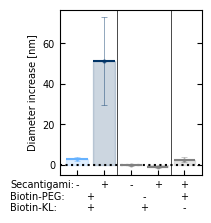

In [8]:
# 2. Main comparison bar/ scatter plots (Data type: II, Topic: A)
# Part IIa: Plot 1: Biotin-KL and the negative controls

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Paths of the data files
input_path = os.path.join(OUT_DIR, "variants_groupmeans.csv")
difference_input_path = os.path.join(OUT_DIR, "variants_differences.csv")

# read in the data
data = pd.read_csv(input_path)
difference_data = pd.read_csv(difference_input_path)

# Define color code
colors = [blue1, blue2, 'grey', 'grey', 'grey']

# Define group order: S = Secantigami added, A = Aptamer added, AS = both. Sample 1: Aptamer is Biotin-KL, sample 2: Same as sample 1 but no biotinylated lipids in the SUVs, sample 7: no addition of aptamer.
order = ['1 BSUVs', '1 BSUVs A', '1 BSUVs AS', '2 DSUVs', '2 DSUVs A', '2 DSUVs AS', '7 BSUVs', '7 BSUVs S']

# sort the data
data['Order'] = data['Main Group'].apply(lambda x: order.index(x) if x in order else np.nan)
data = data.sort_values(by='Order')

# filter to get only the data important for this plot
data_filtered = data.dropna(subset=['Order'])

group_names = ['+', '+', '-'] # Custom labels for the addition of aptamer
lipid_names = ['+', '-', '+'] # Custom labels for the presence of biotinylated lipids

# main function
def main_plot_overall(data, difference_data, y_limits=None):
    fig, ax = plt.subplots(figsize=(6/2.54, 6/2.54)) # devide by 2.54 to get inch from cm.

    x_positions = range(len(data)) # define x-positions
    
    bars = ax.bar(x_positions, data['Overall_Mean'], color=colors, edgecolor= colors, alpha=0.2) # Add faint bars

    # Draw a line at the top of each bar (The overall mean value)
    for idx, mean in enumerate(data['Overall_Mean']):
        ax.hlines(
            y=mean,                       # y-position of the line (mean)
            xmin=idx - 0.4,               # start of the line
            xmax=idx + 0.4,               # end of the line
            color=colors[idx],            # Color is the same as the bars
            linewidth=1.5,                # Width of the line
            alpha=1                       # occupacity
        )

    # Add scatter plot
    for idx, group in enumerate(data['Main Group']):
        # Filter the points and errors for the current group
        #group_points = difference_data[difference_data['Group'].str[2:] == group]['Delta Mean']
        group_points= np.mean(difference_data[difference_data['Group'].str[2:] == group]['Delta Mean'])
        print(len(difference_data[difference_data['Group'].str[2:] == group]['Delta Mean']))
        #group_errors = difference_data[difference_data['Group'].str[2:] == group]['Delta SEM']
        group_errors = np.std(difference_data[difference_data['Group'].str[2:] == group]['Delta Mean'])/np.sqrt(len(difference_data[difference_data['Group'].str[2:] == group]['Delta Mean']))
        
        # Plot each point with an error bar
        ax.errorbar(
            np.full(1, idx),  # x positions
            group_points,                     # y values
            yerr=group_errors,                # y errors
            fmt='o',                          # point marker
            color=colors[idx],                # point color (the same as the bar and the line)
            markersize=2,                     # point size
            alpha=0.6,                        # transparency
            capsize=2.5,                      # error cap size
            elinewidth=0.5,                   # error line width
            capthick=0.5,                     # cap thickness
            zorder=2                          # layering
        )

    # Add labels
    ax.set_ylabel('Diameter increase [nm]', fontsize=7)

    # Edit the axes
    ax.tick_params(axis='y', labelsize=7)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(['-' if i % 2 == 0 and i != 4 else '+' for i in x_positions], fontsize=7)
    ax.yaxis.set_ticks_position('both')
    ax.tick_params(axis='both', direction='in')

    # Add vertical lines to devide the groups
    ax.axvline(x=3.5, color='black', linestyle='-', linewidth=0.5)
    ax.axvline(x=1.5, color='black', linestyle='-', linewidth=0.5)

    # Place aptamer information under the x-axis
    for idx, name in enumerate(group_names):
        if idx < 2:
            ax.text(idx * 2 + 0.5, -0.17, name, ha='center', va='top', 
                    transform=ax.get_xaxis_transform(), fontsize=7)
        else:     
            ax.text(idx * 2, -0.17, name, ha='center', va='top', 
                    transform=ax.get_xaxis_transform(), fontsize=7)
            
    # Add text in the "legend"
    ax.text(-2.5, -0.03, "Secantigami:", ha='left', va='top', 
            transform=ax.get_xaxis_transform(), fontsize=7)     
    ax.text(-2.5, -0.1, "Biotin-PEG:", ha='left', va='top', 
            transform=ax.get_xaxis_transform(), fontsize=7) 
    ax.text(-2.5, -0.17, "Biotin-KL:", ha='left', va='top', 
            transform=ax.get_xaxis_transform(), fontsize=7)
    
    # Place lipid information under the x-axis
    for idx, name in enumerate(lipid_names):
        if idx < 2:
            ax.text(idx * 2 + 0.5, -0.1, name, ha='center', va='top', 
                    transform=ax.get_xaxis_transform(), fontsize=7)   
        else:     
            ax.text(idx * 2, -0.1, name, ha='center', va='top', 
                    transform=ax.get_xaxis_transform(), fontsize=7)

    # Possibly change y-axis size
    if y_limits:
        ax.set_ylim(y_limits)
    else:
        ax.set_ylim(-5,)  # Standard

    # Add a dotted horizontal line at y=0
    ax.axhline(y=0, color='black', linestyle='dotted', zorder=1)

    # Show and save plot
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "combined_Biotin-KL.png"), format='png', dpi=300, bbox_inches='tight', pad_inches=0.1) # The directory might needs to be added first.
    plt.savefig(os.path.join(FIG_DIR, "combined_Biotin-KL.svg"), format='svg', dpi=300, bbox_inches='tight', pad_inches=0.1)
    plt.show()

# Call function
if not data_filtered.empty:
    main_plot_overall(data_filtered, difference_data)  # A defined y-range can be set here.

## 3 · Figure 3E — screening of the aptamer variants

Reuses the processed tables written in section 2, so **run section 2 first**.
Output: `output/graphs/combined_Variants.svg`

Diameter increase for Biotin-KL and the three engineered variants V1-KL, V2-KL
and V3-KL, with and without SecAntiGami.

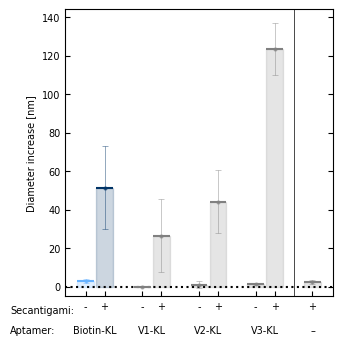

In [9]:
# 2. Main comparison bar/ scatter plots (Data type: II, Topic: A)
# Part IIb: Plot 2: Variant screening

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Paths of the data files
input_path = os.path.join(OUT_DIR, "variants_groupmeans.csv")
difference_input_path = os.path.join(OUT_DIR, "variants_differences.csv")

# Read in the data
data = pd.read_csv(input_path)
difference_data = pd.read_csv(difference_input_path)

# Define color code
colors=[blue1, blue2, 'gray','gray','gray','gray','gray','gray','gray']

# Define group order:  S = Secantigami added, A = Aptamer added, AS = both. Sample 1: Aptamer is Biotin-KL, sample 3: Aptamer is V1-KL, sample 4: Aptamer is V2-KL, sample 6: Aptamer is V3-KL, sample 7: no addition of aptamer.
order = ['1 BSUVs', '1 BSUVs A', '1 BSUVs AS', '3 BSUVs', '3 BSUVs A', '3 BSUVs AS', '4 BSUVs', '4 BSUVs A', '4 BSUVs AS', 
         '6 BSUVs', '6 BSUVs A', '6 BSUVs AS', '7 BSUVs', '7 BSUVs S']

# Label and sort data
data['Order'] = data['Main Group'].apply(lambda x: order.index(x) if x in order else np.nan)
data = data.sort_values(by='Order')

# Filter data to only have the data needed for this plot
data_filtered = data.dropna(subset=['Order'])

group_names = ['Biotin-KL', 'V1-KL', 'V2-KL', 'V3-KL', '–'] # Custom labels for the aptamers
sao_names = ['-', '+', '-', '+', '-', '+', '-', '+', '+'] # Custom labels for the addition of Secantigami

# Main function
def main_plot_overall(data, difference_data, y_limits=None):
    cm_to_inch = lambda cm: cm / 2.54 # convert cm to inch
    fig, ax = plt.subplots(figsize=(cm_to_inch(9), cm_to_inch(9)), dpi=100) # Define size of the plot

    x_positions = [0.9, 1.3, 2.1, 2.5, 3.3, 3.7, 4.5, 4.9, 5.7] # Define costum x-positions to place corresponding samples closer together
    x_names = [1.1, 2.3, 3.5, 4.7, 5.7] # Define the x-positions of the labels for two bars (Middle between two corresponding samples.)
    
    # Add faint bar plot
    ax.bar(x_positions,data['Overall_Mean'] , width=0.35, color=colors, edgecolor=colors, alpha=0.2)

    # Draw a line at the top of each bar (The overall mean value)
    for idx, mean in enumerate(data['Overall_Mean']):
        ax.hlines(
            y=mean,                             # y-position of the line (mean)
            xmin=x_positions[idx] - 0.175,      # start of the line
            xmax=x_positions[idx] + 0.175,      # end of the line
            color=colors[idx],                  # Color is the same as the bars
            linewidth=1.5,                      # Width of the line
            alpha=1                             # occupacity
        )

    # Add scatter plot
    for idx, group in enumerate(data['Main Group']):
        # Filter the points and errors for the current group
        #group_points = difference_data[difference_data['Group'].str[2:] == group]['Delta Mean']
        
        group_points = np.mean(difference_data[difference_data['Group'].str[2:] == group]['Delta Mean'])

        #group_errors = difference_data[difference_data['Group'].str[2:] == group]['Delta SEM']
        
        group_errors = np.std(difference_data[difference_data['Group'].str[2:] == group]['Delta Mean'])/np.sqrt(len(difference_data[difference_data['Group'].str[2:] == group]['Delta Mean']))

        
        # Plot each point with an error bar
        ax.errorbar(
            np.full(1, x_positions[idx]), # x positions
            group_points,                     # y values
            yerr=group_errors,                # y errors
            fmt='o',                          # point marker
            color=colors[idx],                # point color
            markersize=2,                     # point size
            alpha=0.6,                        # transparency
            capsize=2.5,                      # error cap size
            elinewidth=0.5,                   # error line width
            capthick=0.5,                     # cap thickness
            zorder=2                          # layering
        )

    # Add labels for y-axis
    ax.set_ylabel('Diameter increase [nm]', fontsize=7)

    #Edit axes
    ax.tick_params(axis='y', labelsize=7)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(sao_names, fontsize=7)
    ax.yaxis.set_ticks_position('both')
    ax.tick_params(axis='both', direction='in')

    # Add a vertical line to separate the negative control
    ax.axvline(x=5.3, color='black', linestyle='-', linewidth=0.5)

    # Add text in the "legend"
    ax.text(-0.7, -0.03, "Secantigami:", ha='left', va='top', transform=ax.get_xaxis_transform(), fontsize=7)     
    ax.text(-0.7, -0.1, "Aptamer:", ha='left', va='top', transform=ax.get_xaxis_transform(), fontsize=7)     

    # Place aptamer information under the x-axis
    for idx, name in enumerate(group_names):
        if idx < 2:
            ax.text(x_names[idx], -0.1, name, ha='center', va='top', 
                    transform=ax.get_xaxis_transform(), fontsize=7)   
        else:     
            ax.text(x_names[idx], -0.1, name, ha='center', va='top', 
                    transform=ax.get_xaxis_transform(), fontsize=7)

    # Set costum y-range
    if y_limits:
        ax.set_ylim(y_limits)
    else:
        ax.set_ylim(-5,)  # Standard

    # Add a horizontal line at y=0
    ax.axhline(y=0, color='black', linestyle='dotted', zorder=1)

    # Show and save plot
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "combined_Variants.png"), format='png', dpi=300, bbox_inches='tight', pad_inches=0.1) # The directory might needs to be added first.
    plt.savefig(os.path.join(FIG_DIR, "combined_Variants.svg"), format='svg', dpi=300, bbox_inches='tight', pad_inches=0.1)
    plt.show()

# Call function
if not data_filtered.empty:
    main_plot_overall(data_filtered, difference_data)  # A defined y-range can be set here.

## 4 · Supplementary Figure S8d — SecAntiGami-1KL and N-Biotin-KL

Inputs: `250827_Linus_Peaks_reformatted.txt`, `250905_Linus_Peaks_1to8_reformatted.txt`, `250905_measurement9_for_barplot.txt`
Output: `output/graphs/4KL_1KL_NBio_combined.svg`

Diameter increase caused by SecAntiGami carrying one kissing loop rather than
four, and by the binding-site knock-out aptamer N-Biotin-KL.

These measurements were acquired on a different instrument (Zetasizer Ultra,
Malvern) with a different spectrophotometer and RNA purification columns, as
described in the Supporting Information.

This section writes its processed tables under the `figS8_` prefix so that it
cannot overwrite the intermediates produced by sections 2 and 3.

In [10]:
# 2. Main comparison bar/ scatter plots (Data type II, Topic A)
# Part Ia: Data analysis: Aggregate the technical triplicates to calculate mean, standard deviation and standard error of the mean (SEM)
# The main problem here is that all samples with the same conditions but from different experiments have the exact same name. To identify them, one data set was split and suffixes were attached to each name.


# Paths to the input files. Here, each experiment has its own file.
file_paths = [
    os.path.join(DATA_DIR, "250827_Linus_Peaks_reformatted.txt"),
    os.path.join(DATA_DIR, "250905_Linus_Peaks_1to8_reformatted.txt"),
    os.path.join(DATA_DIR, "250905_measurement9_for_barplot.txt")
]

# Assigned prefixes for the triplicates based on file association
triplicate_prefixes = ['A','B', 'C']

def data_processing(file_path, prefix):
    #Reads in the file, truncates the last two characters of the group name (the triplicate numbering), and calculates mean, STD, and SEM of the triplicates using the data 
    # in the `Pk 1 Mean Int (d.nm)` column (which holds the information about the main peak of the distribution) using `ufloat` for uncertainty tracking.
    try:
        # Read file and replace commas in the `Pk 1 Mean Int (d.nm)` column
        df = pd.read_csv(file_path, sep="\t", encoding='latin1')
        
        # Remove the last two characters in `Sample Name`
        df['Sample Name'] = df['Sample Name'].str[:-2]
        
        # Replace commas with periods and convert to float
        df['Pk 1 Mean Int (d.nm)'] = df['Pk 1 Mean Int (d.nm)'].replace(',', '.', regex=True).astype(float)
        
        # Calculate mean, standard deviation, and SEM for each group
        results = []
        for group, data in df.groupby('Sample Name'):
            values = data['Pk 1 Mean Int (d.nm)']
            mean_value = np.mean(values)
            std_value = np.std(values, ddof=1) # SD calculation with n-1
            sem_value = std_value / np.sqrt(len(values))  # SEM calculation
            
            # Create `ufloat` object for the mean with SEM as the uncertainty 
            mean_with_uncertainty = ufloat(mean_value, sem_value)
            
            results.append({
                'Group': f"{prefix} {group}",
                'Mean': mean_with_uncertainty.nominal_value,
                'Std': std_value,
                'SEM': sem_value,
                'Mean_with_uncertainty': mean_with_uncertainty,
                'Source': file_path
            })

        return pd.DataFrame(results)
    except Exception as e:
        print(f"Error reading the file {file_path}: {e}")
        return pd.DataFrame()  # Return an empty DataFrame if there's an error

# Main DataFrame to collect results from all files
combined_results = pd.DataFrame()

# Iterate over files and process
for i, path in enumerate(file_paths):
    prefix = triplicate_prefixes[i]
    file_results = data_processing(path, prefix)
    combined_results = pd.concat([combined_results, file_results], ignore_index=True)

# Output of combined results
print("Results from all files with triplicate distinction (including SEM and STD):")
print(combined_results[['Group', 'Mean', 'Std', 'SEM', 'Mean_with_uncertainty']])

# Save to a CSV file
output_path = os.path.join(OUT_DIR, "figS8_combined_triplicates.csv")
combined_results.to_csv(output_path, index=False)
print(f"The results have been saved to '{output_path}'.")

Results from all files with triplicate distinction (including SEM and STD):
                 Group        Mean       Std       SEM Mean_with_uncertainty
0            A 1 BSUVs  132.166667  3.403430  1.964971           132.2+/-2.0
1        A 1 BSUVs Bio  131.966667  3.043572  1.757207           132.0+/-1.8
2    A 1 BSUVs Bio 4KL  189.033333  5.169462  2.984590           189.0+/-3.0
3            A 2 DSUVs  144.166667  2.193931  1.266667           144.2+/-1.3
4        A 2 DSUVs Bio  143.033333  1.331666  0.768838           143.0+/-0.8
5    A 2 DSUVs Bio 4KL  143.400000  2.535744  1.464013           143.4+/-1.5
6            A 3 BSUVs  131.633333  1.871719  1.080638           131.6+/-1.1
7       A 3 BSUVs NBio  128.233333  2.040425  1.178040           128.2+/-1.2
8   A 3 BSUVs NBio 4KL  130.366667  3.007214  1.736216           130.4+/-1.7
9            A 4 BSUVs  128.800000  0.953939  0.550757           128.8+/-0.6
10       A 4 BSUVs Bio  130.200000  1.946792  1.123981           130.2+/-1.1


In [11]:
# 2. Main comparison bar/ scatter plots (Data type: II, Topic: A)
# Part Ib: Data analysis: Calculate differences to the sample without RNA (the reference sample). (Calculating the increase out of the absolute size values)

# Read the output file containing triplicate results with ufloat
input_path = os.path.join(OUT_DIR, "figS8_combined_triplicates.csv")
data = pd.read_csv(input_path)

# Function to calculate differences with uncertainty propagation
def calculate_differences(data):
    # Identify reference and comparison rows
    reference_rows = data[data['Group'].str.contains("SUVs") & ~data['Group'].str.contains(" 4KL| 1KL| NBio| Bio")] # S = Secantigami added, A = Aptamer added, AS = both (The reference has no addition!)
    comparison_rows = data[data['Group'].str.contains("SUVs") & data['Group'].str.contains(" 4KL| 1KL| NBio| Bio")]

    results = []
    
    for ref_idx, ref_row in reference_rows.iterrows():
        ref_group = ref_row['Group']
        ref_mean = ufloat(ref_row['Mean'], ref_row['SEM'])  # Use ufloat for reference mean

        # Find comparison groups related to this reference sample
        for comp_idx, comp_row in comparison_rows.iterrows():
            if comp_row['Group'].startswith(ref_group):
                comp_mean = ufloat(comp_row['Mean'], comp_row['SEM'])  # Use ufloat for comparison mean

                # Calculate the differences for means, standard deviations, and SEMs
                delta_mean = comp_mean - ref_mean  # Automatically handles error propagation

                results.append({
                    'Group': comp_row['Group'],
                    'Delta Mean': delta_mean.nominal_value,
                    'Delta SEM': delta_mean.std_dev,  # Propagated SEM
                    'Reference Group': ref_group
                })

    return pd.DataFrame(results)

# Call function and perform calculations
difference_results = calculate_differences(data)

# Display results
print("Difference results between reference and comparison samples:")
print(difference_results)

# Optional: Save results
output_diff_path = os.path.join(OUT_DIR, "figS8_differences.csv")
difference_results.to_csv(output_diff_path, index=False)
print(f"The difference results have been saved at '{output_diff_path}'.")

Difference results between reference and comparison samples:
                 Group  Delta Mean  Delta SEM Reference Group
0        A 1 BSUVs Bio   -0.200000   2.636075       A 1 BSUVs
1    A 1 BSUVs Bio 4KL   56.866667   3.573358       A 1 BSUVs
2        A 2 DSUVs Bio   -1.133333   1.481741       A 2 DSUVs
3    A 2 DSUVs Bio 4KL   -0.766667   1.935918       A 2 DSUVs
4       A 3 BSUVs NBio   -3.400000   1.598611       A 3 BSUVs
5   A 3 BSUVs NBio 4KL   -1.266667   2.045048       A 3 BSUVs
6        A 4 BSUVs Bio    1.400000   1.251666       A 4 BSUVs
7    A 4 BSUVs Bio 1KL   16.966667   2.292984       A 4 BSUVs
8       A 5 DSUVs NBio    2.033333   3.483453       A 5 DSUVs
9   A 5 DSUVs NBio 4KL   -0.533333   1.540202       A 5 DSUVs
10       A 6 DSUVs Bio    4.000000   2.149935       A 6 DSUVs
11   A 6 DSUVs Bio 1KL    4.566667   2.729062       A 6 DSUVs
12       A 7 BSUVs 4KL   -0.800000   1.817202       A 7 BSUVs
13       A 8 BSUVs 1KL   -0.600000   2.157674       A 8 BSUVs
14       

In [12]:
# 2. Main comparison bar/ scatter plots (Data type: II, Topic: A)
# Part Ic: Data analysis: Calculate the means of a sample throughout all experiments.

import os
import pandas as pd
import numpy as np
from uncertainties import ufloat

# Input path
input_path = os.path.join(OUT_DIR, "figS8_differences.csv")

# Read the difference results file
data = pd.read_csv(input_path)

# Remove the first two characters from the 'Group' name to identify main groups (The first two characters contain the prefix used to distinguish between the experiments.)
data['Main Group'] = data['Group'].str[2:]

# Function to calculate propagated SEM using ufloat
def calculate_sem_error_propagation(uncertainties):
    propagated_value = ufloat(0, 0)  # Start with a ufloat object with zero value
    for u in uncertainties:
        propagated_value += u  # Accumulate using ufloat
    return propagated_value.std_dev / np.sqrt(len(uncertainties))  # Propagated SEM

# Calculate overall mean, propagated STD, and SEM for each main group
grouped_results = data.groupby('Main Group').agg(
    Overall_Mean=('Delta Mean', 'mean'),
    Propagated_SEM=('Delta SEM', lambda x: calculate_sem_error_propagation([ufloat(mean, sem) for mean, sem in zip(x, data.loc[x.index, 'Delta SEM'])]))
).reset_index()

# Display results
print("Group means:")
print(grouped_results)

# Save results to a new CSV file
output_path = os.path.join(OUT_DIR, "figS8_groupmeans.csv")
grouped_results.to_csv(output_path, index=False)
print(f"The grouped means, standard deviations, and SEMs (with error propagation) have been saved to '{output_path}'.")

Group means:
          Main Group  Overall_Mean  Propagated_SEM
0        1 BSUVs Bio     -0.044444        1.654735
1    1 BSUVs Bio 4KL     44.200000        3.293765
2        2 DSUVs Bio     -1.383333        1.235134
3    2 DSUVs Bio 4KL     -0.316667        1.943651
4       3 BSUVs NBio     -2.016667        2.106340
5   3 BSUVs NBio 4KL      0.016667        2.073510
6        4 BSUVs Bio      2.216667        1.146977
7    4 BSUVs Bio 1KL     19.250000        2.736989
8       5 DSUVs NBio      0.016667        2.595188
9   5 DSUVs NBio 4KL      0.433333        1.611590
10       6 DSUVs Bio      4.000000        2.535197
11   6 DSUVs Bio 1KL      3.766667        2.041650
12       7 BSUVs 4KL     -1.133333        1.727233
13       8 BSUVs 1KL     -0.900000        1.820867
The grouped means, standard deviations, and SEMs (with error propagation) have been saved to '/Users/wverstra/Desktop/Main_author_projects/Secantigami/Nano letters submission/Gallery proof/Code/output/figS8_groupmeans.csv'

/Users/wverstra/miniconda3/envs/ribozymes_env/lib/python3.11/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


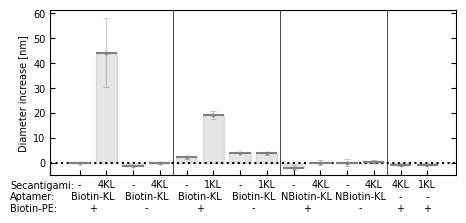

In [13]:
# 2. Main comparison bar/ scatter plots (Data type: II, Topic: A)
# Part IIa: Plot 1: Biotin-KL and the negative controls

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Paths of the data files
input_path = os.path.join(OUT_DIR, "figS8_groupmeans.csv")
difference_input_path = os.path.join(OUT_DIR, "figS8_differences.csv")

# read in the data
data = pd.read_csv(input_path)
difference_data = pd.read_csv(difference_input_path)

# Define group order: S = Secantigami added, A = Aptamer added, AS = both. Sample 1: Aptamer is Biotin-KL, sample 2: Same as sample 1 but no biotinylated lipids in the SUVs, sample 7: no addition of aptamer.
order = ['1 BSUVs', '1 BSUVs Bio', '1 BSUVs Bio 4KL', '2 DSUVs', '2 DSUVs Bio', '2 DSUVs Bio 4KL', '4 BSUVs', '4 BSUVs Bio', '4 BSUVs Bio 1KL', '6 DSUVs', '6 DSUVs Bio', '6 DSUVs Bio 1KL', '3 BSUVs', '3 BSUVs NBio', '3 BSUVs NBio 4KL','5 DSUVs', '5 DSUVs NBio', '5 DSUVs NBio 4KL', '7 BSUVs', '7 BSUVs 4KL', '8 BSUVs', '8 BSUVs 1KL']

# Define color code
colors = ['grey'] * (len(order))

# sort the data
data['Order'] = data['Main Group'].apply(lambda x: order.index(x) if x in order else np.nan)
data = data.sort_values(by='Order')

# filter to get only the data important for this plot
data_filtered = data.dropna(subset=['Order'])

group_names = ['Biotin-KL', 'Biotin-KL', 'Biotin-KL', 'Biotin-KL', 'NBiotin-KL', 'NBiotin-KL', '-', '-'] # Custom labels for the addition of aptamer
lipid_names = ['+', '-', '+', '-', '+', '-', '+', '+',] # Custom labels for the presence of biotinylated lipids

# main function
def main_plot_overall(data, difference_data, y_limits=None):
    fig, ax = plt.subplots(figsize=(12/2.54, 6/2.54)) # devide by 2.54 to get inch from cm.

    x_positions = range(len(data)) # define x-positions
    
    bars = ax.bar(x_positions, data['Overall_Mean'], color=colors, edgecolor= colors, alpha=0.2) # Add faint bars

    # Draw a line at the top of each bar (The overall mean value)
    for idx, mean in enumerate(data['Overall_Mean']):
        ax.hlines(
            y=mean,                       # y-position of the line (mean)
            xmin=idx - 0.4,               # start of the line
            xmax=idx + 0.4,               # end of the line
            color=colors[idx],            # Color is the same as the bars
            linewidth=1.5,                # Width of the line
            alpha=1                       # occupacity
        )

    # Add scatter plot
    for idx, group in enumerate(data['Main Group']):
        # Filter the points and errors for the current group
        group_points = difference_data[difference_data['Group'].str[2:] == group]['Delta Mean']
        group_points = np.mean(difference_data[difference_data['Group'].str[2:] == group]['Delta Mean']) 
        group_errors = difference_data[difference_data['Group'].str[2:] == group]['Delta SEM']
        group_errors = np.std(difference_data[difference_data['Group'].str[2:] == group]['Delta Mean'])/np.sqrt(len(difference_data[difference_data['Group'].str[2:] == group]['Delta Mean'])) # To get only one point per group, the mean of the points is calculated. This is done to avoid overplotting.
        
        # Plot each point with an error bar
        ax.errorbar(
            np.full(1, idx),  # x positions
            group_points,                     # y values
            yerr=group_errors,                # y errors
            fmt='o',                          # point marker
            color=colors[idx],                # point color (the same as the bar and the line)
            markersize=2,                     # point size
            alpha=0.6,                        # transparency
            capsize=2.5,                      # error cap size
            elinewidth=0.5,                   # error line width
            capthick=0.5,                     # cap thickness
            zorder=2                          # layering
        )

    # Add labels
    ax.set_ylabel('Diameter increase [nm]', fontsize=7)

    # Edit the axes
    ax.tick_params(axis='y', labelsize=7)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(['-' if i % 2 == 0 and i != 12 else '1KL' if i == 5 or i == 7 or i == 13 else '4KL' for i in x_positions], fontsize=7)
    ax.yaxis.set_ticks_position('both')
    ax.tick_params(axis='both', direction='in')

    # Add vertical lines to devide the groups
    ax.axvline(x=3.5, color='black', linestyle='-', linewidth=0.5)
    ax.axvline(x=7.5, color='black', linestyle='-', linewidth=0.5)
    ax.axvline(x=11.5, color='black', linestyle='-', linewidth=0.5)

    # Place aptamer information under the x-axis
    for idx, name in enumerate(group_names):
        if idx < 6:
            ax.text(idx * 2 + 0.5, -0.1, name, ha='center', va='top', 
                    transform=ax.get_xaxis_transform(), fontsize=7)
        elif idx == 6:
            ax.text(12, -0.1, name, ha='center', va='top', 
                    transform=ax.get_xaxis_transform(), fontsize=7)
        else:     
            ax.text(13, -0.1, name, ha='center', va='top', 
                    transform=ax.get_xaxis_transform(), fontsize=7)
            
    # Add text in the "legend"
    ax.text(-2.6, -0.03, "Secantigami:", ha='left', va='top', 
            transform=ax.get_xaxis_transform(), fontsize=7)     
    ax.text(-2.6, -0.17, "Biotin-PE:", ha='left', va='top', 
            transform=ax.get_xaxis_transform(), fontsize=7) 
    ax.text(-2.6, -0.1, "Aptamer:", ha='left', va='top', 
            transform=ax.get_xaxis_transform(), fontsize=7)
    
    # Place lipid information under the x-axis
    for idx, name in enumerate(lipid_names):
        if idx < 6:
            ax.text(idx * 2 + 0.5, -0.17, name, ha='center', va='top', 
                    transform=ax.get_xaxis_transform(), fontsize=7)   
        elif idx == 6:    
            ax.text(12, -0.17, name, ha='center', va='top', 
                    transform=ax.get_xaxis_transform(), fontsize=7)
        else:
            ax.text(13, -0.17, name, ha='center', va='top', 
                    transform=ax.get_xaxis_transform(), fontsize=7)

    # Possibly change y-axis size
    if y_limits:
        ax.set_ylim(y_limits)
    else:
        ax.set_ylim(-5,)  # Standard

    # Add a dotted horizontal line at y=0
    ax.axhline(y=0, color='black', linestyle='dotted', zorder=1)

    # Show and save plot
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "4KL_1KL_NBio_combined.png"), format='png', dpi=300, bbox_inches='tight', pad_inches=0.1) # The directory might needs to be added first.
    plt.savefig(os.path.join(FIG_DIR, "4KL_1KL_NBio_combined.svg"), format='svg', dpi=300, bbox_inches='tight', pad_inches=0.1)
    plt.show()

# Call function
if not data_filtered.empty:
    main_plot_overall(data_filtered, difference_data)  # A defined y-range can be set here.